In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/capm_clean_full.csv", low_memory=False)

print("Dimensions :", df.shape)
df.head()

Dimensions : (37045, 103)


,id_ligne,code_dossier,date_reception,annee_reception,heure_reception,type_rapport,sous_type_rapport,type_declarant,sous_type_declarant,service,...,source,observation_vigilance,grade_initiale_serpent,grade_finale_serpent,age_calcule_mois,pss_initial,pss_final,cible_valide,annee_reception_clean,age_annee_clean
0,212329,M79/2020,2020-01-01,2020.0,17H30,Spontané,Réponse téléphonique,Professionnel de santé,Médecin,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,5.0,False,2020.0,45.0
1,212330,M81/2020,2020-01-01,2020.0,21H50,Spontané,Réponse téléphonique,Public,Public,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,2.0,True,2020.0,25.0
2,212331,M86/2020,2020-01-01,2020.0,16H37,Spontané,Réponse téléphonique,Professionnel de santé,Médecin,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,2.0,True,2020.0,20.0
3,212332,2721/2020,2020-01-01,2020.0,02:01:00,Spontané,Réponse téléphonique,Professionnel de santé,Médecin,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,5.0,False,2020.0,16.0
4,212333,3060/2020,2020-01-01,2020.0,19:30:00,Spontané,Réponse téléphonique,Professionnel de santé,Médecin,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,2.0,True,2020.0,16.0


In [3]:
print(df["pss_final"].value_counts(dropna=False).sort_index())
print()
print("Pourcentages :")
print((df["pss_final"].value_counts(normalize=True, dropna=False).sort_index() * 100).round(1))

pss_final
0.0    7919
1.0    3473
2.0    9723
3.0     590
4.0     135
5.0    8750
NaN    6455
Name: count, dtype: int64

Pourcentages :
pss_final
0.0    21.4
1.0     9.4
2.0    26.2
3.0     1.6
4.0     0.4
5.0    23.6
NaN    17.4
Name: proportion, dtype: float64


C:\Users\Micro\AppData\Local\Temp\ipykernel_23568\2196162246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df["cible_valide"]], x="pss_final", palette="viridis")


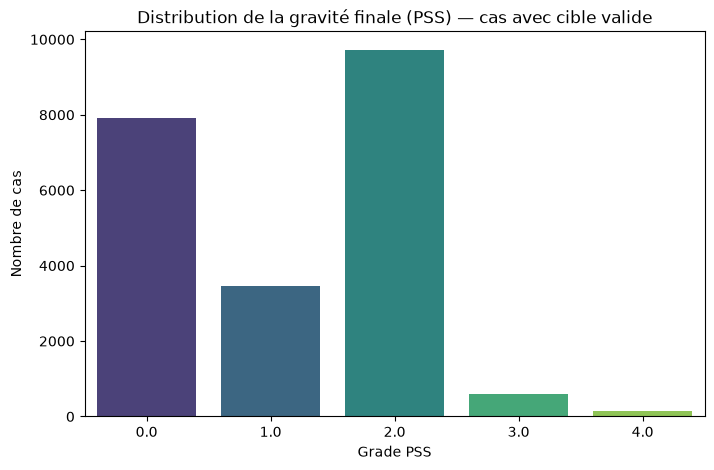

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df["cible_valide"]], x="pss_final", palette="viridis")
plt.title("Distribution de la gravité finale (PSS) — cas avec cible valide")
plt.xlabel("Grade PSS")
plt.ylabel("Nombre de cas")
plt.show()

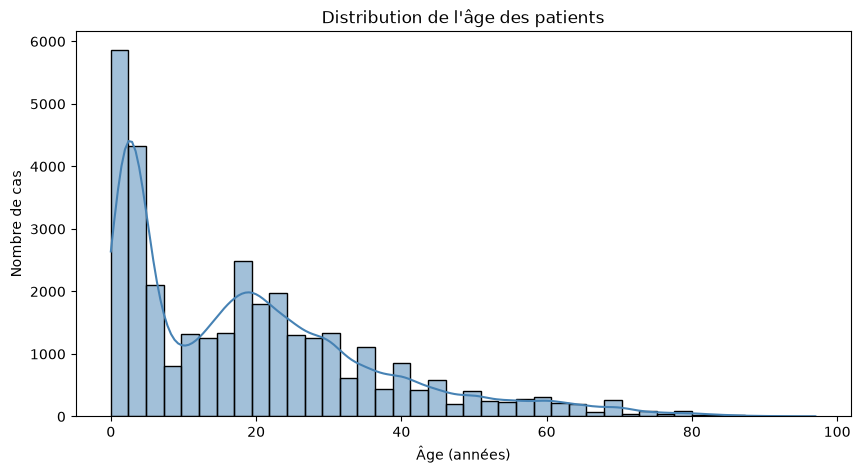

count    34012.000000
mean        19.130032
std         17.386827
min          0.000000
25%          3.000000
50%         16.000000
75%         28.000000
max         97.000000
Name: age_annee_clean, dtype: float64


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age_annee_clean", bins=40, kde=True, color="steelblue")
plt.title("Distribution de l'âge des patients")
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de cas")
plt.show()

print(df["age_annee_clean"].describe())

C:\Users\Micro\AppData\Local\Temp\ipykernel_23568\1719381691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="tranche_age", order=df["tranche_age"].value_counts().index, ax=axes[0], palette="magma")
C:\Users\Micro\AppData\Local\Temp\ipykernel_23568\1719381691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sexe", ax=axes[1], palette="pastel")


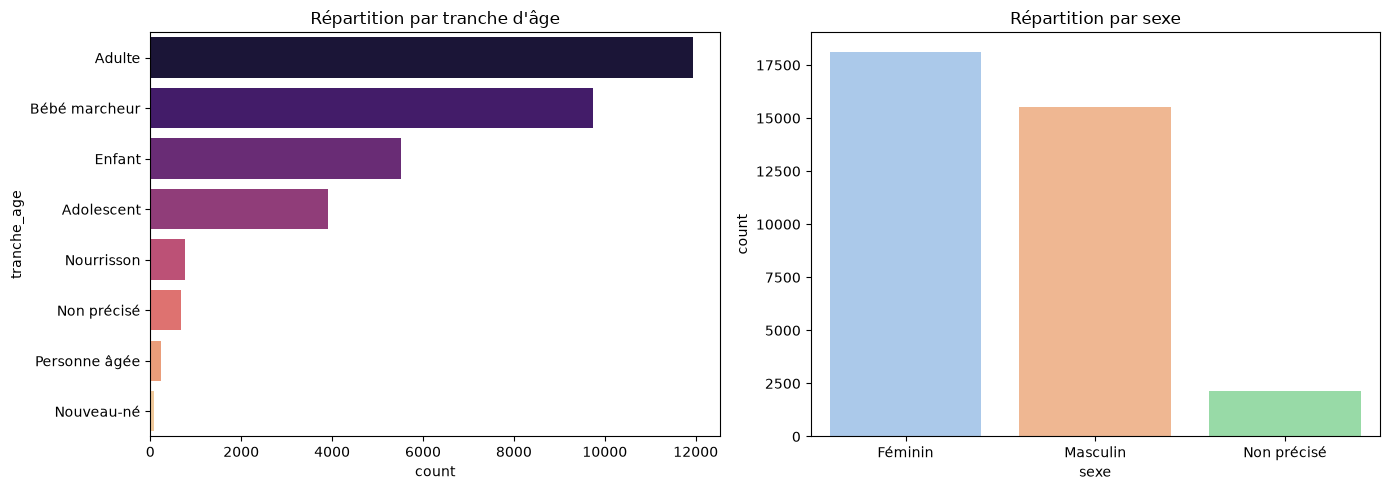

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y="tranche_age", order=df["tranche_age"].value_counts().index, ax=axes[0], palette="magma")
axes[0].set_title("Répartition par tranche d'âge")

sns.countplot(data=df, x="sexe", ax=axes[1], palette="pastel")
axes[1].set_title("Répartition par sexe")

plt.tight_layout()
plt.show()

C:\Users\Micro\AppData\Local\Temp\ipykernel_23568\3153416710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["cible_valide"]], x="pss_final", y="age_annee_clean", palette="coolwarm")


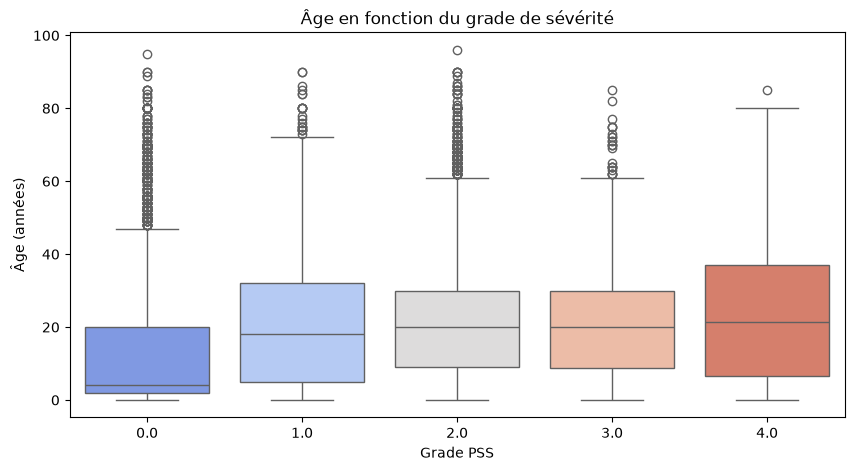

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["cible_valide"]], x="pss_final", y="age_annee_clean", palette="coolwarm")
plt.title("Âge en fonction du grade de sévérité")
plt.xlabel("Grade PSS")
plt.ylabel("Âge (années)")
plt.show()

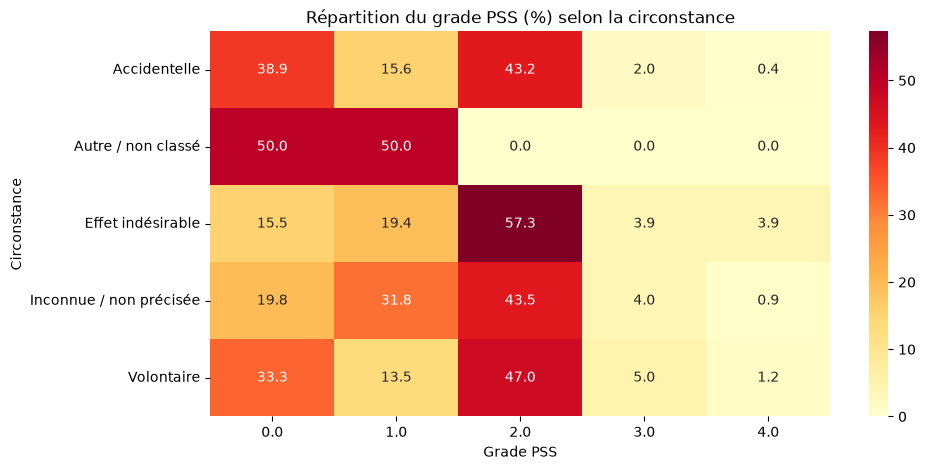

In [8]:
ct = pd.crosstab(df[df["cible_valide"]]["circonstance"], df[df["cible_valide"]]["pss_final"], normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Répartition du grade PSS (%) selon la circonstance")
plt.xlabel("Grade PSS")
plt.ylabel("Circonstance")
plt.show()

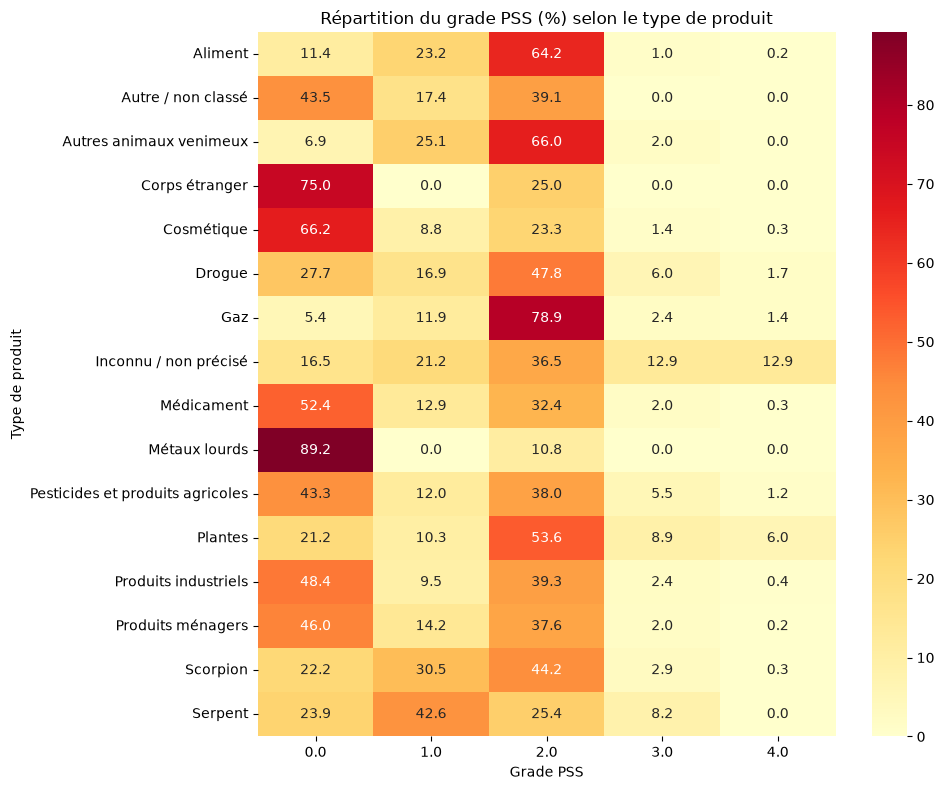

In [9]:
ct2 = pd.crosstab(
    df[df["cible_valide"]]["type_produit_1"],
    df[df["cible_valide"]]["pss_final"],
    normalize="index"
) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(ct2, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Répartition du grade PSS (%) selon le type de produit")
plt.xlabel("Grade PSS")
plt.ylabel("Type de produit")
plt.tight_layout()
plt.show()

In [10]:
print(df[df["cible_valide"]]["type_produit_1"].value_counts())

type_produit_1
Médicament                          8311
Aliment                             3826
Pesticides et produits agricoles    2403
Gaz                                 1694
Produits industriels                1271
Produits ménagers                   1253
Drogue                               712
Scorpion                             650
Autres animaux venimeux              494
Serpent                              477
Plantes                              302
Cosmétique                           296
Inconnu / non précisé                 85
Métaux lourds                         37
Autre / non classé                    23
Corps étranger                         4
Name: count, dtype: int64
